# Cross-Region Generalization Analysis

This notebook evaluates how the trained multi-task model generalizes across regions.

Outputs generated:
- per-region metrics CSV
- region failure analysis CSV
- summary plots for report use

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rasterio
from rasterio.enums import Resampling
from rasterio.errors import RasterioIOError

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import f1_score, roc_auc_score, mean_absolute_error
from tqdm.auto import tqdm

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("device:", device)

device: cpu


d:\DHRUVA\CVP\computervisionflooddetection\.venv314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
repo_root = Path(".").resolve()
out_dir = repo_root / "proxy_outputs"
mask_dir = out_dir / "masks_temporal"
ckpt_dir = repo_root / "checkpoints_multitask"
analysis_dir = out_dir / "cross_region_analysis"
analysis_dir.mkdir(parents=True, exist_ok=True)

split_manifest_path = out_dir / "severity_split_manifest.csv"
proxy_path = out_dir / "proxy_labels_severity.csv"
best_ckpt = ckpt_dir / "best_multitask_unet.pt"

if not split_manifest_path.exists():
    raise FileNotFoundError(f"Missing: {split_manifest_path}")
if not proxy_path.exists():
    raise FileNotFoundError(f"Missing: {proxy_path}")
if not best_ckpt.exists():
    raise FileNotFoundError(f"Missing: {best_ckpt}")

split_df = pd.read_csv(split_manifest_path)
proxy_df = pd.read_csv(proxy_path)

for df in [split_df, proxy_df]:
    df["region_norm"] = df["region"].astype(str).str.strip().str.lstrip("0").replace("", "0")
    df["date"] = df["date"].astype(str)

test_df = split_df[split_df["split"].astype(str).str.lower() == "test"].copy()

meta_cols = ["region_norm", "scene_id", "date", "method", "water_fraction_temporal", "persistence_score", "delta_score", "quality_score"]
meta = proxy_df[[c for c in meta_cols if c in proxy_df.columns]].drop_duplicates(["region_norm", "scene_id", "date"])
test_df = test_df.merge(meta, how="left", on=["region_norm", "scene_id", "date"])

test_df["severity_bin"] = test_df["severity_bin"].astype(int)
test_df["flood_label"] = (test_df["severity_bin"] > 0).astype(np.float32)
test_df["local_mask_path"] = test_df["temporal_mask_path"].astype(str).apply(lambda x: str(mask_dir / Path(x).name))

print("test rows before filtering:", len(test_df))
display(test_df.head(3))

test rows before filtering: 120


,region,scene_id,date,severity_bin,severity_score,water_fraction_temporal_x,temporal_mask_path,s2_b02,s2_b03,s2_b04,...,s1_vh_gap_days,split,region_norm,method,water_fraction_temporal_y,persistence_score,delta_score,quality_score,flood_label,local_mask_path
0,301,S2_2019-01-09,2019-01-09,3,0.750090,0.894806,proxy_outputs/masks_temporal/0301__S2_2019-01-...,SEN12FLOOD/0301/S2_2019-01-09_B02.tif,SEN12FLOOD/0301/S2_2019-01-09_B03.tif,SEN12FLOOD/0301/S2_2019-01-09_B04.tif,...,9,test,301,S2_NDWI_mNDWI,0.894806,0.789851,0.104955,1.0,1.0,D:\DHRUVA\CVP\computervisionflooddetection\pro...
1,301,S2_2019-02-13,2019-02-13,3,0.774926,0.927921,proxy_outputs/masks_temporal/0301__S2_2019-02-...,SEN12FLOOD/0301/S2_2019-02-13_B02.tif,SEN12FLOOD/0301/S2_2019-02-13_B03.tif,SEN12FLOOD/0301/S2_2019-02-13_B04.tif,...,1,test,301,S2_NDWI_mNDWI,0.927921,0.789851,0.138070,1.0,1.0,D:\DHRUVA\CVP\computervisionflooddetection\pro...
2,301,S2_2019-02-28,2019-02-28,3,0.794510,0.954033,proxy_outputs/masks_temporal/0301__S2_2019-02-...,SEN12FLOOD/0301/S2_2019-02-28_B02.tif,SEN12FLOOD/0301/S2_2019-02-28_B03.tif,SEN12FLOOD/0301/S2_2019-02-28_B04.tif,...,5,test,301,S2_NDWI_mNDWI,0.954033,0.789851,0.164182,1.0,1.0,D:\DHRUVA\CVP\computervisionflooddetection\pro...


In [3]:
def path_exists(p):
    return Path(str(p)).exists()

required_paths = ["s2_b02", "s2_b03", "s2_b04", "s2_b08", "s2_b11", "s1_vv", "s1_vh", "local_mask_path"]
for c in required_paths:
    test_df[f"{c}_ok"] = test_df[c].apply(path_exists)

ok_mask = np.logical_and.reduce([test_df[f"{c}_ok"].values for c in required_paths])
eval_df = test_df[ok_mask].copy().reset_index(drop=True)

print("rows with all files present:", len(eval_df), "out of", len(test_df))
if len(eval_df) == 0:
    raise RuntimeError("No valid test rows after path filtering.")

display(eval_df[["region_norm", "scene_id", "severity_bin", "method"]].head(5))

rows with all files present: 120 out of 120


,region_norm,scene_id,severity_bin,method
0,301,S2_2019-01-09,3,S2_NDWI_mNDWI
1,301,S2_2019-02-13,3,S2_NDWI_mNDWI
2,301,S2_2019-02-28,3,S2_NDWI_mNDWI
3,301,S2_2019-03-15,2,S2_NDWI_mNDWI
4,303,S2_2019-01-09,0,S2_NDWI_mNDWI


In [4]:
def safe_read_single_band(path, target_hw=None, resampling=Resampling.bilinear):
    try:
        with rasterio.open(path) as src:
            if target_hw is None:
                arr = src.read(1).astype(np.float32)
            else:
                h, w = target_hw
                arr = src.read(1, out_shape=(h, w), resampling=resampling).astype(np.float32)
        return arr
    except Exception as e:
        raise RasterioIOError(f"Could not read raster: {path}") from e


def read_s1_vv_vh(vv_path, vh_path, target_hw=None):
    vv = safe_read_single_band(vv_path, target_hw=target_hw)
    vh = safe_read_single_band(vh_path, target_hw=target_hw)
    return np.stack([vv, vh], axis=0).astype(np.float32)


def sar_to_unit(x):
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    x = 10.0 * np.log10(np.clip(x, 1e-6, None))
    x = np.clip(x, -35.0, 5.0)
    x = (x + 35.0) / 40.0
    return x.astype(np.float32)


def optical_to_unit(x):
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    x = x / 10000.0
    x = np.clip(x, 0.0, 1.0)
    return x.astype(np.float32)


def resize_mask_nearest(mask, target_hw):
    th, tw = target_hw
    h, w = mask.shape
    if (h, w) == (th, tw):
        return mask.astype(np.float32)
    y_idx = np.linspace(0, h - 1, th).round().astype(int)
    x_idx = np.linspace(0, w - 1, tw).round().astype(int)
    out = mask[np.ix_(y_idx, x_idx)]
    return out.astype(np.float32)


def build_7ch_tensor(row):
    b02 = safe_read_single_band(row["s2_b02"])
    h, w = b02.shape
    b03 = safe_read_single_band(row["s2_b03"], (h, w))
    b04 = safe_read_single_band(row["s2_b04"], (h, w))
    b08 = safe_read_single_band(row["s2_b08"], (h, w))
    b11 = safe_read_single_band(row["s2_b11"], (h, w))

    s1 = read_s1_vv_vh(row["s1_vv"], row["s1_vh"], (h, w))
    vv = sar_to_unit(s1[0])
    vh = sar_to_unit(s1[1])

    x = np.stack([
        vv,
        vh,
        optical_to_unit(b02),
        optical_to_unit(b03),
        optical_to_unit(b04),
        optical_to_unit(b08),
        optical_to_unit(b11),
    ], axis=0)
    return x.astype(np.float32)


class FloodMultiTaskDataset(Dataset):
    def __init__(self, frame):
        self.df = frame.reset_index(drop=True).copy()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = build_7ch_tensor(row)

        mask = np.load(row["local_mask_path"]).astype(np.float32)
        mask = (mask > 0).astype(np.float32)
        mask = resize_mask_nearest(mask, x.shape[1:])

        return {
            "image": torch.from_numpy(x),
            "mask": torch.from_numpy(mask).unsqueeze(0),
            "flood_label": torch.tensor(np.float32(row["flood_label"]), dtype=torch.float32),
            "severity_bin": torch.tensor(np.int64(row["severity_bin"]), dtype=torch.long),
            "region": torch.tensor(np.int64(int(row["region_norm"])), dtype=torch.long),
            "scene_id": row["scene_id"],
        }

In [5]:
class ConvBlock(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(cin, cout, 3, padding=1, bias=False),
            nn.BatchNorm2d(cout),
            nn.ReLU(inplace=True),
            nn.Conv2d(cout, cout, 3, padding=1, bias=False),
            nn.BatchNorm2d(cout),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class FloodUNetMultiTask(nn.Module):
    def __init__(self, in_ch=7, widths=(32, 64, 128, 256, 512)):
        super().__init__()
        w1, w2, w3, w4, wb = widths

        self.enc1 = ConvBlock(in_ch, w1)
        self.enc2 = ConvBlock(w1, w2)
        self.enc3 = ConvBlock(w2, w3)
        self.enc4 = ConvBlock(w3, w4)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(w4, wb)

        self.up4 = nn.ConvTranspose2d(wb, w4, kernel_size=2, stride=2)
        self.dec4 = ConvBlock(w4 + w4, w4)
        self.up3 = nn.ConvTranspose2d(w4, w3, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(w3 + w3, w3)
        self.up2 = nn.ConvTranspose2d(w3, w2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(w2 + w2, w2)
        self.up1 = nn.ConvTranspose2d(w2, w1, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(w1 + w1, w1)

        self.seg_head = nn.Conv2d(w1, 1, kernel_size=1)
        self.det_head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(wb, 1))
        self.sev_head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(wb, 3))

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        if d4.shape[-2:] != e4.shape[-2:]:
            d4 = F.interpolate(d4, size=e4.shape[-2:], mode="bilinear", align_corners=False)
        d4 = self.dec4(torch.cat([e4, d4], dim=1))

        d3 = self.up3(d4)
        if d3.shape[-2:] != e3.shape[-2:]:
            d3 = F.interpolate(d3, size=e3.shape[-2:], mode="bilinear", align_corners=False)
        d3 = self.dec3(torch.cat([e3, d3], dim=1))

        d2 = self.up2(d3)
        if d2.shape[-2:] != e2.shape[-2:]:
            d2 = F.interpolate(d2, size=e2.shape[-2:], mode="bilinear", align_corners=False)
        d2 = self.dec2(torch.cat([e2, d2], dim=1))

        d1 = self.up1(d2)
        if d1.shape[-2:] != e1.shape[-2:]:
            d1 = F.interpolate(d1, size=e1.shape[-2:], mode="bilinear", align_corners=False)
        d1 = self.dec1(torch.cat([e1, d1], dim=1))

        seg_logits = self.seg_head(d1)
        det_logit = self.det_head(b).squeeze(1)
        sev_logits = self.sev_head(b)
        return seg_logits, det_logit, sev_logits


def logits_to_severity(sev_logits):
    return (torch.sigmoid(sev_logits) > 0.5).long().sum(dim=1)

In [6]:
test_ds = FloodMultiTaskDataset(eval_df)

# On Windows notebooks, multi-worker DataLoader commonly crashes with raster/torch I/O.
# Keep workers at 0 for stable inference.
if os.name == "nt":
    num_workers = 0
else:
    num_workers = 0 if device.type == "mps" else min(4, os.cpu_count() or 1)

test_loader = DataLoader(
    test_ds,
    batch_size=4,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=(device.type == "cuda"),
)

print("num_workers:", num_workers)

model = FloodUNetMultiTask().to(device)
state = torch.load(best_ckpt, map_location=device)
model.load_state_dict(state)
model.eval()

records = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="infer test"):
        x = batch["image"].to(device)
        m = batch["mask"].to(device)
        y_det = batch["flood_label"].to(device)
        y_sev = batch["severity_bin"].to(device)

        seg_logits, det_logit, sev_logits = model(x)
        seg_prob = torch.sigmoid(seg_logits)
        seg_pred = (seg_prob > 0.5).float()
        det_prob = torch.sigmoid(det_logit)
        det_pred = (det_prob > 0.5).long()
        sev_pred = logits_to_severity(sev_logits)

        inter = (seg_pred * m).reshape(m.size(0), -1).sum(dim=1).detach().cpu().numpy()
        union = (seg_pred + m - seg_pred * m).reshape(m.size(0), -1).sum(dim=1).detach().cpu().numpy()

        regions = batch["region"].detach().cpu().numpy()
        scenes = list(batch["scene_id"])

        for i in range(len(regions)):
            records.append({
                "region": int(regions[i]),
                "scene_id": scenes[i],
                "seg_inter": float(inter[i]),
                "seg_union": float(union[i]),
                "det_true": int(y_det[i].item()),
                "det_prob": float(det_prob[i].item()),
                "det_pred": int(det_pred[i].item()),
                "sev_true": int(y_sev[i].item()),
                "sev_pred": int(sev_pred[i].item()),
            })

pred_df = pd.DataFrame(records)
pred_path = analysis_dir / "test_predictions_by_scene.csv"
pred_df.to_csv(pred_path, index=False)
print("saved:", pred_path)
print("prediction rows:", len(pred_df))
display(pred_df.head(5))

num_workers: 0


infer test: 100%|██████████| 30/30 [05:12<00:00, 10.43s/it]

saved: D:\DHRUVA\CVP\computervisionflooddetection\proxy_outputs\cross_region_analysis\test_predictions_by_scene.csv
prediction rows: 120


,region,scene_id,seg_inter,seg_union,det_true,det_prob,det_pred,sev_true,sev_pred
0,301,S2_2019-01-09,234568.0,262144.0,1,0.999975,1,3,3
1,301,S2_2019-02-13,243249.0,262144.0,1,0.999990,1,3,3
2,301,S2_2019-02-28,163099.0,251527.0,1,0.988566,1,3,2
3,301,S2_2019-03-15,100308.0,262049.0,1,0.999995,1,2,3
4,303,S2_2019-01-09,20323.0,34460.0,0,0.978683,1,0,2


In [7]:
region_rows = []
for region, g in pred_df.groupby("region"):
    iou_vals = np.where(g["seg_union"].values > 0, g["seg_inter"].values / g["seg_union"].values, 1.0)
    det_true = g["det_true"].values
    det_pred = g["det_pred"].values
    det_prob = g["det_prob"].values
    sev_true = g["sev_true"].values
    sev_pred = g["sev_pred"].values

    row = {
        "region": int(region),
        "n_samples": int(len(g)),
        "seg_iou": float(np.mean(iou_vals)),
        "det_f1": float(f1_score(det_true, det_pred, zero_division=0)),
        "sev_macro_f1": float(f1_score(sev_true, sev_pred, average="macro", zero_division=0)),
        "sev_mae": float(mean_absolute_error(sev_true, sev_pred)),
    }

    if len(np.unique(det_true)) > 1:
        row["det_auroc"] = float(roc_auc_score(det_true, det_prob))
    else:
        row["det_auroc"] = np.nan

    region_rows.append(row)

region_metrics = pd.DataFrame(region_rows).sort_values("region").reset_index(drop=True)
region_metrics["low_sample"] = region_metrics["n_samples"] < 3

region_metrics_path = analysis_dir / "region_metrics.csv"
region_metrics.to_csv(region_metrics_path, index=False)

print("saved:", region_metrics_path)
display(region_metrics.head(10))
print("regions total:", len(region_metrics), "| low-sample regions:", int(region_metrics["low_sample"].sum()))

C:\Users\dhruv\AppData\Local\Temp\ipykernel_2096\787366258.py:3: RuntimeWarning: invalid value encountered in divide
  iou_vals = np.where(g["seg_union"].values > 0, g["seg_inter"].values / g["seg_union"].values, 1.0)
C:\Users\dhruv\AppData\Local\Temp\ipykernel_2096\787366258.py:3: RuntimeWarning: invalid value encountered in divide
  iou_vals = np.where(g["seg_union"].values > 0, g["seg_inter"].values / g["seg_union"].values, 1.0)


saved: D:\DHRUVA\CVP\computervisionflooddetection\proxy_outputs\cross_region_analysis\region_metrics.csv


C:\Users\dhruv\AppData\Local\Temp\ipykernel_2096\787366258.py:3: RuntimeWarning: invalid value encountered in divide
  iou_vals = np.where(g["seg_union"].values > 0, g["seg_inter"].values / g["seg_union"].values, 1.0)
C:\Users\dhruv\AppData\Local\Temp\ipykernel_2096\787366258.py:3: RuntimeWarning: invalid value encountered in divide
  iou_vals = np.where(g["seg_union"].values > 0, g["seg_inter"].values / g["seg_union"].values, 1.0)


,region,n_samples,seg_iou,det_f1,sev_macro_f1,sev_mae,det_auroc,low_sample
0,301,4,0.713486,1.0,0.333333,0.50,NaN,False
1,303,4,0.724022,0.0,0.222222,0.75,NaN,False
2,304,4,0.684153,0.0,1.000000,0.00,NaN,False
3,305,4,0.956964,1.0,0.333333,0.50,NaN,False
4,306,4,0.976228,1.0,1.000000,0.00,NaN,False
5,307,4,0.951459,1.0,1.000000,0.00,NaN,False
6,308,4,0.789735,1.0,1.000000,0.00,NaN,False
7,309,4,0.000000,0.0,1.000000,0.00,NaN,False
8,310,4,0.286228,0.0,1.000000,0.00,NaN,False
9,311,4,0.353429,0.0,1.000000,0.00,NaN,False


regions total: 30 | low-sample regions: 0


In [8]:
meta_agg = eval_df.copy()
meta_agg["region"] = meta_agg["region_norm"].astype(int)

# Build aggregation map only from columns that actually exist.
base_aggs = {
    "water_fraction_temporal": "mean",
    "s1_vv_gap_days": "median",
    "s1_vh_gap_days": "median",
}
agg_dict = {k: v for k, v in base_aggs.items() if k in meta_agg.columns}
if "method" in meta_agg.columns:
    agg_dict["method"] = lambda s: s.mode().iloc[0] if len(s.mode()) else np.nan

if agg_dict:
    region_meta = meta_agg.groupby("region", as_index=False).agg(agg_dict)
else:
    region_meta = meta_agg[["region"]].drop_duplicates().reset_index(drop=True)

analysis_df = region_metrics.merge(region_meta, on="region", how="left")

# Ensure expected columns exist even when source metadata is missing.
for col in ["water_fraction_temporal", "s1_vv_gap_days", "s1_vh_gap_days", "method"]:
    if col not in analysis_df.columns:
        analysis_df[col] = np.nan

analysis_df["flag_arid_low_water"] = analysis_df["water_fraction_temporal"].fillna(0) < 0.05
analysis_df["flag_temporal_gap"] = analysis_df["s1_vv_gap_days"].fillna(0) > 5
analysis_df["flag_sar_fallback"] = analysis_df["method"].astype(str).str.contains("S1", na=False)
analysis_df["flag_perf_drop"] = (
    (analysis_df["seg_iou"] < 0.35)
    | (analysis_df["det_f1"] < 0.7)
    | (analysis_df["sev_macro_f1"] < 0.5)
)

analysis_df["failure_tag"] = np.select(
    [
        analysis_df["flag_perf_drop"] & analysis_df["flag_temporal_gap"],
        analysis_df["flag_perf_drop"] & analysis_df["flag_arid_low_water"],
        analysis_df["flag_perf_drop"] & analysis_df["flag_sar_fallback"],
        analysis_df["flag_perf_drop"],
    ],
    [
        "temporal_mismatch",
        "arid_or_sparse_water",
        "sar_fallback_sensitive",
        "general_low_performance",
    ],
    default="stable",
)

analysis_path = analysis_dir / "region_failure_analysis.csv"
analysis_df.to_csv(analysis_path, index=False)

print("saved:", analysis_path)
print("aggregated columns:", sorted(agg_dict.keys()))
display(analysis_df.sort_values(["failure_tag", "seg_iou"]).head(15))

saved: D:\DHRUVA\CVP\computervisionflooddetection\proxy_outputs\cross_region_analysis\region_failure_analysis.csv
aggregated columns: ['method', 's1_vh_gap_days', 's1_vv_gap_days']


,region,n_samples,seg_iou,det_f1,sev_macro_f1,sev_mae,det_auroc,low_sample,s1_vv_gap_days,s1_vh_gap_days,method,water_fraction_temporal,flag_arid_low_water,flag_temporal_gap,flag_sar_fallback,flag_perf_drop,failure_tag
27,334,4,0.372293,0.0,1.0,0.0,NaN,False,3.5,3.5,S2_NDWI_mNDWI,NaN,True,False,False,True,arid_or_sparse_water
26,333,4,0.630043,0.0,1.0,0.0,NaN,False,3.5,3.5,S2_NDWI_mNDWI,NaN,True,False,False,True,arid_or_sparse_water
6,308,4,0.789735,1.0,1.0,0.0,NaN,False,6.5,6.5,S2_NDWI_mNDWI,NaN,True,True,False,False,stable
5,307,4,0.951459,1.0,1.0,0.0,NaN,False,6.5,6.5,S2_NDWI_mNDWI,NaN,True,True,False,False,stable
4,306,4,0.976228,1.0,1.0,0.0,NaN,False,6.5,6.5,S2_NDWI_mNDWI,NaN,True,True,False,False,stable
7,309,4,0.000000,0.0,1.0,0.0,NaN,False,6.5,6.5,S2_NDWI_mNDWI,NaN,True,True,False,True,temporal_mismatch
19,326,4,0.000000,0.0,1.0,0.0,NaN,False,6.5,6.5,S2_NDWI_mNDWI,NaN,True,True,False,True,temporal_mismatch
20,327,4,0.010854,0.0,1.0,0.0,NaN,False,6.5,6.5,S2_NDWI_mNDWI,NaN,True,True,False,True,temporal_mismatch
12,318,4,0.016753,0.0,1.0,0.0,NaN,False,6.5,6.5,S2_NDWI_mNDWI,NaN,True,True,False,True,temporal_mismatch
13,319,4,0.042313,0.0,1.0,0.0,NaN,False,6.5,6.5,S2_NDWI_mNDWI,NaN,True,True,False,True,temporal_mismatch


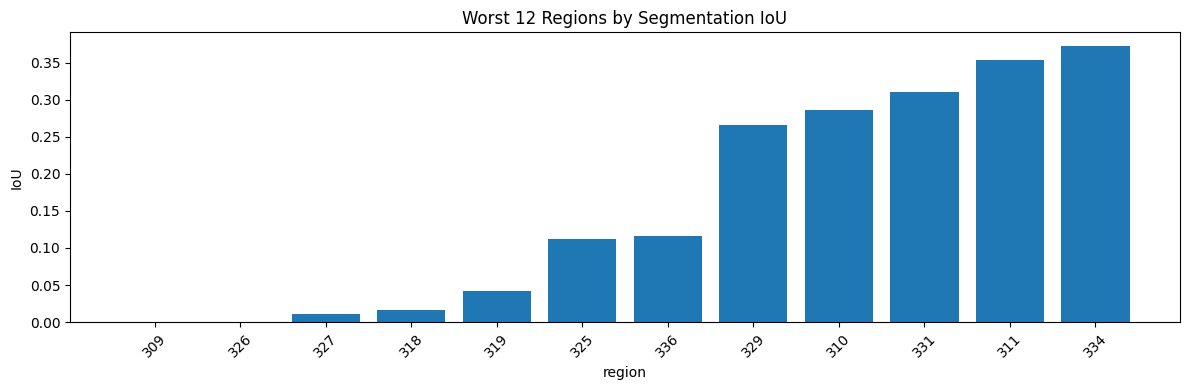

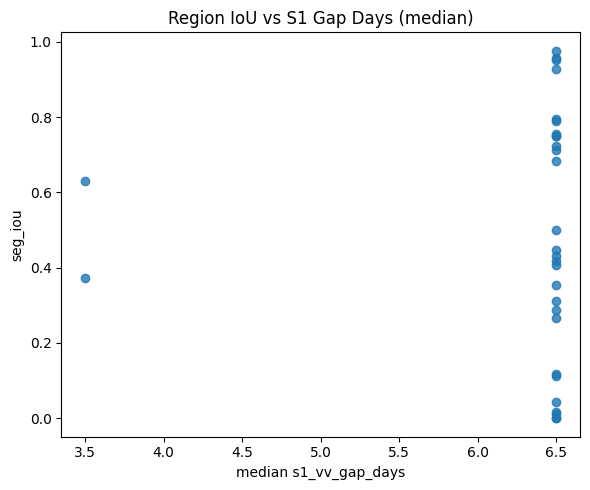

,method,seg_iou,det_f1,sev_macro_f1
0,S2_NDWI_mNDWI,0.483121,0.233333,0.88836


In [9]:
plt.figure(figsize=(12, 4))
worst_iou = analysis_df.sort_values("seg_iou").head(12)
plt.bar(worst_iou["region"].astype(str), worst_iou["seg_iou"].values)
plt.title("Worst 12 Regions by Segmentation IoU")
plt.xlabel("region")
plt.ylabel("IoU")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(analysis_df["s1_vv_gap_days"], analysis_df["seg_iou"], alpha=0.8)
plt.title("Region IoU vs S1 Gap Days (median)")
plt.xlabel("median s1_vv_gap_days")
plt.ylabel("seg_iou")
plt.tight_layout()
plt.show()

if "method" in analysis_df.columns:
    method_view = analysis_df.groupby("method", as_index=False)[["seg_iou", "det_f1", "sev_macro_f1"]].mean()
    display(method_view.sort_values("seg_iou"))

## TTA and BN Adaptation Experiment

This section compares four inference strategies on the same held-out test set:

1. Baseline (no TTA, no BN adaptation)
2. TTA only (flip-based test-time augmentation)
3. BN adaptation only (refresh BN running stats on target test distribution)
4. BN adaptation + TTA



In [10]:
import copy


def tta_logits(model, x):
    preds = []

    # identity
    seg, det, sev = model(x)
    preds.append((seg, det, sev))

    # horizontal flip
    x_h = torch.flip(x, dims=[3])
    seg_h, det_h, sev_h = model(x_h)
    seg_h = torch.flip(seg_h, dims=[3])
    preds.append((seg_h, det_h, sev_h))

    # vertical flip
    x_v = torch.flip(x, dims=[2])
    seg_v, det_v, sev_v = model(x_v)
    seg_v = torch.flip(seg_v, dims=[2])
    preds.append((seg_v, det_v, sev_v))

    seg_avg = torch.stack([p[0] for p in preds], dim=0).mean(dim=0)
    det_avg = torch.stack([p[1] for p in preds], dim=0).mean(dim=0)
    sev_avg = torch.stack([p[2] for p in preds], dim=0).mean(dim=0)
    return seg_avg, det_avg, sev_avg


def collect_predictions(model, loader, use_tta=False):
    model.eval()
    rows = []
    with torch.no_grad():
        for batch in tqdm(loader, leave=False):
            x = batch["image"].to(device)
            m = batch["mask"].to(device)
            y_det = batch["flood_label"].to(device)
            y_sev = batch["severity_bin"].to(device)

            if use_tta:
                seg_logits, det_logit, sev_logits = tta_logits(model, x)
            else:
                seg_logits, det_logit, sev_logits = model(x)

            seg_pred = (torch.sigmoid(seg_logits) > 0.5).float()
            det_prob = torch.sigmoid(det_logit)
            det_pred = (det_prob > 0.5).long()
            sev_pred = logits_to_severity(sev_logits)

            inter = (seg_pred * m).reshape(m.size(0), -1).sum(dim=1).detach().cpu().numpy()
            union = (seg_pred + m - seg_pred * m).reshape(m.size(0), -1).sum(dim=1).detach().cpu().numpy()

            regions = batch["region"].detach().cpu().numpy()
            scenes = list(batch["scene_id"])

            for i in range(len(regions)):
                rows.append(
                    {
                        "region": int(regions[i]),
                        "scene_id": scenes[i],
                        "seg_inter": float(inter[i]),
                        "seg_union": float(union[i]),
                        "det_true": int(y_det[i].item()),
                        "det_prob": float(det_prob[i].item()),
                        "det_pred": int(det_pred[i].item()),
                        "sev_true": int(y_sev[i].item()),
                        "sev_pred": int(sev_pred[i].item()),
                    }
                )

    return pd.DataFrame(rows)


def metrics_from_pred_df(df):
    iou_vals = np.where(df["seg_union"] > 0, df["seg_inter"] / df["seg_union"], 1.0)
    det_true = df["det_true"].values
    det_pred = df["det_pred"].values
    det_prob = df["det_prob"].values
    sev_true = df["sev_true"].values
    sev_pred = df["sev_pred"].values

    out = {
        "seg_iou": float(np.mean(iou_vals)),
        "det_f1": float(f1_score(det_true, det_pred, zero_division=0)),
        "sev_macro_f1": float(f1_score(sev_true, sev_pred, average="macro", zero_division=0)),
        "sev_mae": float(mean_absolute_error(sev_true, sev_pred)),
    }
    if len(np.unique(det_true)) > 1:
        out["det_auroc"] = float(roc_auc_score(det_true, det_prob))
    else:
        out["det_auroc"] = np.nan
    return out


def per_region_metrics_from_pred_df(df, strategy_name):
    rows = []
    for region, g in df.groupby("region"):
        iou_vals = np.where(g["seg_union"].values > 0, g["seg_inter"].values / g["seg_union"].values, 1.0)
        det_true = g["det_true"].values
        det_pred = g["det_pred"].values
        det_prob = g["det_prob"].values
        sev_true = g["sev_true"].values
        sev_pred = g["sev_pred"].values

        row = {
            "strategy": strategy_name,
            "region": int(region),
            "n_samples": int(len(g)),
            "seg_iou": float(np.mean(iou_vals)),
            "det_f1": float(f1_score(det_true, det_pred, zero_division=0)),
            "sev_macro_f1": float(f1_score(sev_true, sev_pred, average="macro", zero_division=0)),
            "sev_mae": float(mean_absolute_error(sev_true, sev_pred)),
        }
        if len(np.unique(det_true)) > 1:
            row["det_auroc"] = float(roc_auc_score(det_true, det_prob))
        else:
            row["det_auroc"] = np.nan
        rows.append(row)
    return pd.DataFrame(rows)


def adapt_bn_stats(model, loader, max_batches=None):
    model.train()
    # Update only BN running stats with unlabeled target data.
    for p in model.parameters():
        p.requires_grad = False

    bn_layers = []
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.train()
            bn_layers.append(m)
        else:
            m.eval()

    with torch.no_grad():
        for i, batch in enumerate(loader):
            x = batch["image"].to(device)
            _ = model(x)
            if max_batches is not None and (i + 1) >= max_batches:
                break

    model.eval()
    return len(bn_layers)


# fresh baseline model state
base_model = FloodUNetMultiTask().to(device)
base_model.load_state_dict(torch.load(best_ckpt, map_location=device))
base_model.eval()

strategy_pred = {}
strategy_global = []
strategy_region = []

# 1) baseline
pred_baseline = collect_predictions(base_model, test_loader, use_tta=False)
strategy_pred["baseline"] = pred_baseline
m = metrics_from_pred_df(pred_baseline)
strategy_global.append({"strategy": "baseline", **m})
strategy_region.append(per_region_metrics_from_pred_df(pred_baseline, "baseline"))

# 2) tta only
pred_tta = collect_predictions(base_model, test_loader, use_tta=True)
strategy_pred["tta_only"] = pred_tta
m = metrics_from_pred_df(pred_tta)
strategy_global.append({"strategy": "tta_only", **m})
strategy_region.append(per_region_metrics_from_pred_df(pred_tta, "tta_only"))

# 3) bn adaptation only
bn_model = FloodUNetMultiTask().to(device)
bn_model.load_state_dict(torch.load(best_ckpt, map_location=device))
num_bn = adapt_bn_stats(bn_model, test_loader, max_batches=None)
print("BN layers adapted:", num_bn)

pred_bn = collect_predictions(bn_model, test_loader, use_tta=False)
strategy_pred["bn_only"] = pred_bn
m = metrics_from_pred_df(pred_bn)
strategy_global.append({"strategy": "bn_only", **m})
strategy_region.append(per_region_metrics_from_pred_df(pred_bn, "bn_only"))

# 4) bn + tta
pred_bn_tta = collect_predictions(bn_model, test_loader, use_tta=True)
strategy_pred["bn_plus_tta"] = pred_bn_tta
m = metrics_from_pred_df(pred_bn_tta)
strategy_global.append({"strategy": "bn_plus_tta", **m})
strategy_region.append(per_region_metrics_from_pred_df(pred_bn_tta, "bn_plus_tta"))

# Save outputs
global_cmp = pd.DataFrame(strategy_global)
region_cmp = pd.concat(strategy_region, ignore_index=True)

global_cmp_path = analysis_dir / "tta_bn_comparison_global.csv"
region_cmp_path = analysis_dir / "tta_bn_comparison_region.csv"

global_cmp.to_csv(global_cmp_path, index=False)
region_cmp.to_csv(region_cmp_path, index=False)

print("saved:", global_cmp_path)
print("saved:", region_cmp_path)
display(global_cmp)

# quick delta view vs baseline
base_row = global_cmp[global_cmp["strategy"] == "baseline"].iloc[0]
delta_df = global_cmp.copy()
for col in ["seg_iou", "det_f1", "det_auroc", "sev_macro_f1", "sev_mae"]:
    delta_df[f"delta_{col}"] = delta_df[col] - base_row[col]

display(delta_df)

C:\Users\dhruv\AppData\Local\Temp\ipykernel_2096\794250517.py:97: RuntimeWarning: invalid value encountered in divide
  iou_vals = np.where(g["seg_union"].values > 0, g["seg_inter"].values / g["seg_union"].values, 1.0)
C:\Users\dhruv\AppData\Local\Temp\ipykernel_2096\794250517.py:97: RuntimeWarning: invalid value encountered in divide
  iou_vals = np.where(g["seg_union"].values > 0, g["seg_inter"].values / g["seg_union"].values, 1.0)
C:\Users\dhruv\AppData\Local\Temp\ipykernel_2096\794250517.py:97: RuntimeWarning: invalid value encountered in divide
  iou_vals = np.where(g["seg_union"].values > 0, g["seg_inter"].values / g["seg_union"].values, 1.0)
C:\Users\dhruv\AppData\Local\Temp\ipykernel_2096\794250517.py:97: RuntimeWarning: invalid value encountered in divide
  iou_vals = np.where(g["seg_union"].values > 0, g["seg_inter"].values / g["seg_union"].values, 1.0)
C:\Users\dhruv\AppData\Local\Temp\ipykernel_2096\794250517.py:97: RuntimeWarning: invalid value encountered in divide
  iou_

BN layers adapted: 18


saved: D:\DHRUVA\CVP\computervisionflooddetection\proxy_outputs\cross_region_analysis\tta_bn_comparison_global.csv
saved: D:\DHRUVA\CVP\computervisionflooddetection\proxy_outputs\cross_region_analysis\tta_bn_comparison_region.csv


,strategy,seg_iou,det_f1,sev_macro_f1,sev_mae,det_auroc
0,baseline,0.483121,0.949153,0.612226,0.083333,1.000000
1,tta_only,0.484289,0.918033,0.563889,0.116667,0.999612
2,bn_only,0.219775,0.437500,0.213504,1.316667,0.896739
3,bn_plus_tta,0.220245,0.437500,0.216836,1.308333,0.896739


,strategy,seg_iou,det_f1,sev_macro_f1,sev_mae,det_auroc,delta_seg_iou,delta_det_f1,delta_det_auroc,delta_sev_macro_f1,delta_sev_mae
0,baseline,0.483121,0.949153,0.612226,0.083333,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,tta_only,0.484289,0.918033,0.563889,0.116667,0.999612,0.001168,-0.031120,-0.000388,-0.048337,0.033333
2,bn_only,0.219775,0.437500,0.213504,1.316667,0.896739,-0.263346,-0.511653,-0.103261,-0.398722,1.233333
3,bn_plus_tta,0.220245,0.437500,0.216836,1.308333,0.896739,-0.262877,-0.511653,-0.103261,-0.395390,1.225000


## Cross-Region Generalization Results 

### Methodology
- We evaluated cross-region generalization using the predefined leakage-safe geographic split:
  - train: region <= 250
  - val: 251 to 300
  - test: >= 301
- The held-out test set used in this notebook contains 120 samples from 30 regions (4 samples/region).
- For each test sample, the model produced three outputs:
  1. segmentation mask (IoU from predicted vs proxy mask)
  2. flood detection (F1/AUROC)
  3. severity prediction (macro-F1/MAE)
- We aggregated metrics at both global and per-region levels and exported:
  - `test_predictions_by_scene.csv`
  - `region_metrics.csv`
  - `region_failure_analysis.csv`

### Baseline Cross-Region Performance
- Global metrics on held-out regions:
  - Segmentation IoU: 0.4831
  - Detection F1: 0.9492
  - Detection AUROC: 1.0000
  - Severity macro-F1: 0.6122
  - Severity MAE: 0.0833
- Per-region reliability:
  - low-sample regions (n < 3): 0
  - all 30 regions have exactly 4 samples

### Systematic Failure Patterns
- Failure tag distribution:
  - `temporal_mismatch`: 25 regions
  - `arid_or_sparse_water`: 2 regions
  - `stable`: 3 regions
- Worst segmentation regions (example): 309, 326, 327, 318, 319 (very low IoU and low detection F1), indicating clear region-specific generalization gaps.

### Domain Adaptation Experiments (TTA and BN)
We compared four inference strategies:
1. Baseline
2. TTA only (identity + horizontal flip + vertical flip, logits averaged)
3. BN adaptation only (BN running stats updated on unlabeled test images)
4. BN + TTA

Results summary:
- Baseline: seg_iou 0.4831, det_f1 0.9492, sev_macro_f1 0.6122, sev_mae 0.0833
- TTA only: seg_iou 0.4843, det_f1 0.9180, sev_macro_f1 0.5639, sev_mae 0.1167
- BN only: seg_iou 0.2198, det_f1 0.4375, sev_macro_f1 0.2135, sev_mae 1.3167
- BN + TTA: seg_iou 0.2202, det_f1 0.4375, sev_macro_f1 0.2168, sev_mae 1.3083

Interpretation:
- TTA gave a negligible IoU increase but degraded detection and severity.
- BN adaptation caused substantial performance collapse across all tasks.
- Therefore, baseline inference is the best strategy for this split.

### Key Caveat for Per-Region Metrics
- Because each region has only 4 samples and many regions are single-class for detection/severity, per-region AUROC/F1 can be unstable.
- We therefore use per-region metrics mainly for failure localization (which regions fail) rather than strong statistical claims about ranking precision.

